In [28]:
import numpy as np, pandas as pd
from itertools import combinations
from cluster_lang2vec_distances import build_distance_matrix, auto_k, cluster_with_k
from lang2vec import lang2vec as l2v

# load and filter, only select train split and no _removed subsets
df = pd.read_csv("/home/ubuntu/dice_repos/HTYLLM-PG/approaches/CoLA/data_prep/base_data/fineweb2-language-distribution.csv")
df = df[(df.split == "train") & ~df.subset.str.contains("_removed$", na=False)]

# select top 200 languages by document count
top = (
    df.assign(documents=pd.to_numeric(df.documents, errors="coerce").fillna(0))
      .groupby(["code", "name", "family", "resource_availability"], as_index=False)
      ["documents"].sum()
      .sort_values("documents", ascending=False)
      .head(200)
)

langs = top[top.code.isin(l2v.DISTANCE_LANGUAGES)].reset_index(drop=True)
# keep only the dominant subset per language, problem was i was getting arb_Arab and arb_Latn for Arabic for example
langs = (
    langs.sort_values("documents", ascending=False)
         .drop_duplicates(subset="code", keep="first")
         .reset_index(drop=True)
)

codes = langs.code.tolist()
matrix = build_distance_matrix(codes, "genetic")

def select_expert_clusters(matrix, max_experts=4, min_cluster_size=3):
    best_k, _ = auto_k(matrix, 2, 60, "average", min_cluster_size=min_cluster_size)
    labels = cluster_with_k(matrix, best_k, "average")

    clusters = {
        c: np.where(labels == c)[0]
        for c in np.unique(labels)
        if np.sum(labels == c) >= min_cluster_size
    }

    pairs = [
        (a, b, matrix[np.ix_(ia, ib)].mean())
        for a, ia in clusters.items()
        for b, ib in clusters.items()
        if b > a
    ]

    selected = []
    for a, b, _ in sorted(pairs, key=lambda x: x[2], reverse=True):
        for c in (a, b):
            if c not in selected:
                selected.append(c)
            if len(selected) == max_experts:
                return selected, clusters

    return selected, clusters

def extract_subgroups(indices, matrix, subgroup_size=3, max_subgroups=1):
    idx = list(indices)
    subgroups = []

    for _ in range(max_subgroups):
        if len(idx) < subgroup_size:
            break

        best = min(
            combinations(idx, subgroup_size),
            key=lambda t: np.mean([
                matrix[t[i], t[j]]
                for i in range(subgroup_size)
                for j in range(i+1, subgroup_size)
            ])
        )
        subgroups.append(list(best))
        idx = [i for i in idx if i not in best]

    return subgroups


def plot_selected_experts(matrix, codes, experts):
    import matplotlib.pyplot as plt
    from sklearn.manifold import MDS
    import umap.umap_ as umap
    import numpy as np

    coords_mds = MDS(
        n_components=2, dissimilarity="precomputed", random_state=0
    ).fit_transform(matrix)

    coords_umap = umap.UMAP(
        metric="precomputed", random_state=0
    ).fit_transform(matrix)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # background
    ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
    ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)

    # selected experts only
    for i, exp in enumerate(experts.values()):
        idx = [codes.index(c) for c in exp]

        ax[0].scatter(coords_mds[idx, 0], coords_mds[idx, 1],
                      s=70, label=f"Expert {i}")
        ax[1].scatter(coords_umap[idx, 0], coords_umap[idx, 1],
                      s=70, label=f"Expert {i}")

    ax[0].set_title("MDS – selected experts")
    ax[1].set_title("UMAP – selected experts")
    ax[0].legend()

    plt.tight_layout()
    plt.show()


def print_expert_config(experts, df):
    for i, langs in enumerate(experts.values()):
        print(f"\nExpert {i}")
        print("-" * 20)
        info = (
            df[df.code.isin(langs)]
            [["code", "name", "family", "resource_availability", "subset"]]
            .drop_duplicates(subset="code")
            .sort_values("code")
        )
        print(info.to_string(index=False))




Expert 0
--------------------
code            name       family resource_availability   subset
 aeb Tunisian Arabic Afro-Asiatic                   LOW aeb_Arab
 arb Standard Arabic Afro-Asiatic                  HIGH arb_Arab
 mlt         Maltese Afro-Asiatic                   LOW mlt_Latn

Expert 1
--------------------
code     name        family resource_availability   subset
 fur Friulian Indo-European                   LOW fur_Latn
 roh  Romansh Indo-European                   LOW roh_Latn
 wln  Walloon Indo-European                   LOW wln_Latn

Expert 2
--------------------
code    name            family resource_availability   subset
 ava  Avaric Nakh-Daghestanian                   LOW ava_Cyrl
 che Chechen Nakh-Daghestanian                   LOW che_Cyrl
 inh  Ingush Nakh-Daghestanian                   LOW inh_Cyrl

Expert 3
--------------------
code          name      family resource_availability   subset
 nde North Ndebele Niger-Congo                   LOW nde_Latn
 xho    

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


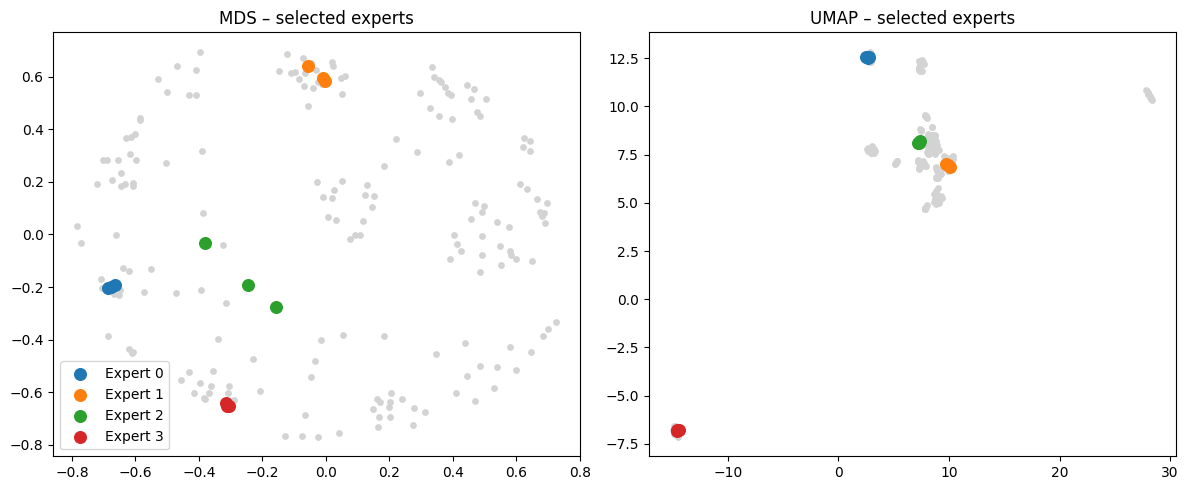

In [29]:
# for tier1 - 12 lang selection

expert_ids, clusters = select_expert_clusters(
    matrix,
    max_experts=4,
    min_cluster_size=3
)

experts = {}
for c in expert_ids:
    subgroups = extract_subgroups(
        clusters[c],
        matrix,
        subgroup_size=3,
        max_subgroups=1
    )
    experts[c] = [codes[i] for i in subgroups[0]]

print_expert_config(experts, df)
plot_selected_experts(matrix, codes, experts)



/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


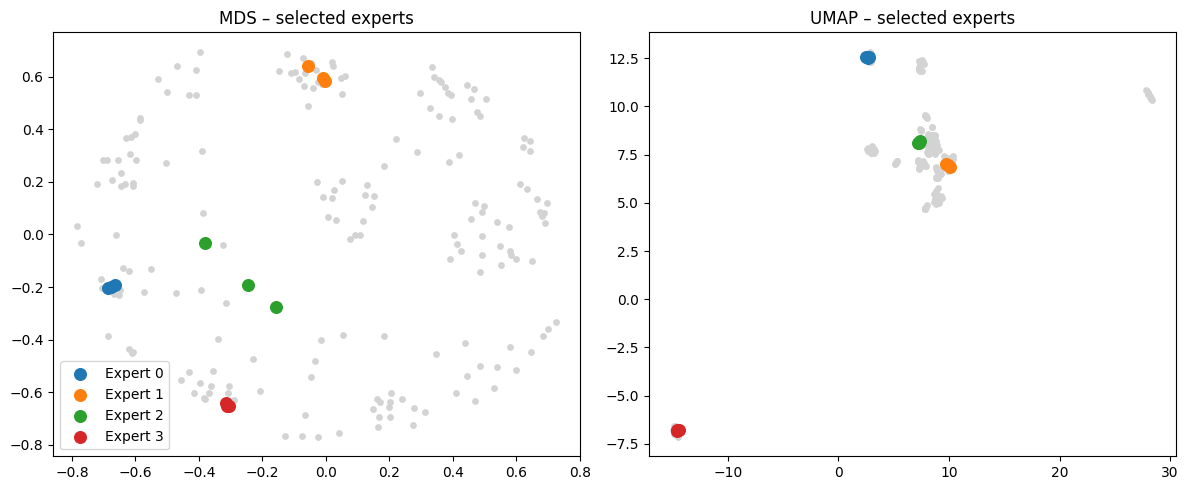


Expert 0
--------------------
code            name       family resource_availability   subset
 aeb Tunisian Arabic Afro-Asiatic                   LOW aeb_Arab
 arb Standard Arabic Afro-Asiatic                  HIGH arb_Arab
 mlt         Maltese Afro-Asiatic                   LOW mlt_Latn

Expert 1
--------------------
code     name        family resource_availability   subset
 fur Friulian Indo-European                   LOW fur_Latn
 roh  Romansh Indo-European                   LOW roh_Latn
 wln  Walloon Indo-European                   LOW wln_Latn

Expert 2
--------------------
code    name            family resource_availability   subset
 ava  Avaric Nakh-Daghestanian                   LOW ava_Cyrl
 che Chechen Nakh-Daghestanian                   LOW che_Cyrl
 inh  Ingush Nakh-Daghestanian                   LOW inh_Cyrl

Expert 3
--------------------
code          name      family resource_availability   subset
 nde North Ndebele Niger-Congo                   LOW nde_Latn
 xho    

In [ ]:
selected_codes = [l for exp in experts.values() for l in exp]

import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import umap.umap_ as umap

# visualize in umap and mds
coords_mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0).fit_transform(matrix)
coords_umap = umap.UMAP(metric="precomputed", random_state=0).fit_transform(matrix)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# background
ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)

# experts (color per expert)
for i, exp in enumerate(experts.values()):
    idx = [codes.index(c) for c in exp]

    ax[0].scatter(coords_mds[idx, 0], coords_mds[idx, 1],
                  s=70, label=f"Expert {i}")
    ax[1].scatter(coords_umap[idx, 0], coords_umap[idx, 1],
                  s=70, label=f"Expert {i}")

ax[0].set_title("MDS – selected experts")
ax[1].set_title("UMAP – selected experts")
ax[0].legend()

plt.tight_layout()
plt.show()


for i, exp in enumerate(experts.values()):
    print(f"\nExpert {i}")
    print("-" * 20)

    info = (
        df.loc[df.code.isin(exp),
               ["code", "name", "family", "resource_availability", "subset"]]
          .drop_duplicates(subset=["code"])
          .sort_values("code")
    )

    print(info.to_string(index=False))

